In [15]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

np.random.seed(67)

In [16]:
# common
def integrated_function(x):
    return 4.0 / (1.0 + x**2)

START = 0.0
END = 1.0
EXACT_VALUE = np.pi

In [17]:
# ex 1
def midpoint_rule(f, a, b, m):
    n = 2**m + 1
    dx = (b - a) / n
    x_mid = np.linspace(a + dx/2, b - dx/2, n)
    return np.sum(f(x_mid)) * dx

n_s = [2**m + 1 for m in range(1, 15)]
err_midpoint, err_trapezoid, err_simpson = [], [], []

for m in range(1, 15):
    number_of_nodes = 2**m + 1
    x_s = np.linspace(START, END, number_of_nodes)
    y_s = integrated_function(x_s)
    
    res_mid = midpoint_rule(integrated_function, START, END, m)
    res_trap = scipy.integrate.trapezoid(y_s, x_s)
    res_simp = scipy.integrate.simpson(y_s, x_s)
    
    err_midpoint.append(np.abs(res_mid - EXACT_VALUE) / EXACT_VALUE)
    err_trapezoid.append(np.abs(res_trap - EXACT_VALUE) / EXACT_VALUE)
    err_simpson.append(np.abs(res_simp - EXACT_VALUE) / EXACT_VALUE)

In [18]:
# ex 2
err_legendre = []
for m in range(1, 15):
    n = 2**m + 1
    res_leg, _ = scipy.integrate.fixed_quad(integrated_function, START, END, n=n)
    err_legendre.append(np.abs(res_leg - EXACT_VALUE) / EXACT_VALUE)

In [19]:
# ex 3
tolerances = np.logspace(0, -14, 20)
evals_adapt_trapz, err_adapt_trapz = [], []
evals_adapt_gk, err_adapt_gk = [], []

for tol in tolerances:
    res_t, _, info_t = scipy.integrate.quad_vec(
        integrated_function, START, END, epsrel=tol, epsabs=tol, quadrature='trapezoid', full_output=True)
    evals_adapt_trapz.append(info_t.neval)
    err_adapt_trapz.append(np.abs(res_t - EXACT_VALUE) / EXACT_VALUE)
    
    res_gk, _, info_gk = scipy.integrate.quad_vec(
        integrated_function, START, END, epsrel=tol, epsabs=tol, quadrature='gk21', full_output=True)
    evals_adapt_gk.append(info_gk.neval)
    err_adapt_gk.append(np.abs(res_gk - EXACT_VALUE) / EXACT_VALUE)

# Zabezpieczenie przed log(0)
err_adapt_trapz = np.maximum(err_adapt_trapz, 1e-16)
err_adapt_gk = np.maximum(err_adapt_gk, 1e-16)

In [20]:
# ex 4
n_values_mc = np.logspace(1, 6, num=50, dtype=int)
err_mc = []

for n in n_values_mc:
    x_random = np.random.uniform(START, END, n)
    integral_mc = np.mean(integrated_function(x_random))
    err_mc.append(np.abs(integral_mc - EXACT_VALUE) / EXACT_VALUE)

err_mc = np.maximum(err_mc, 1e-16)

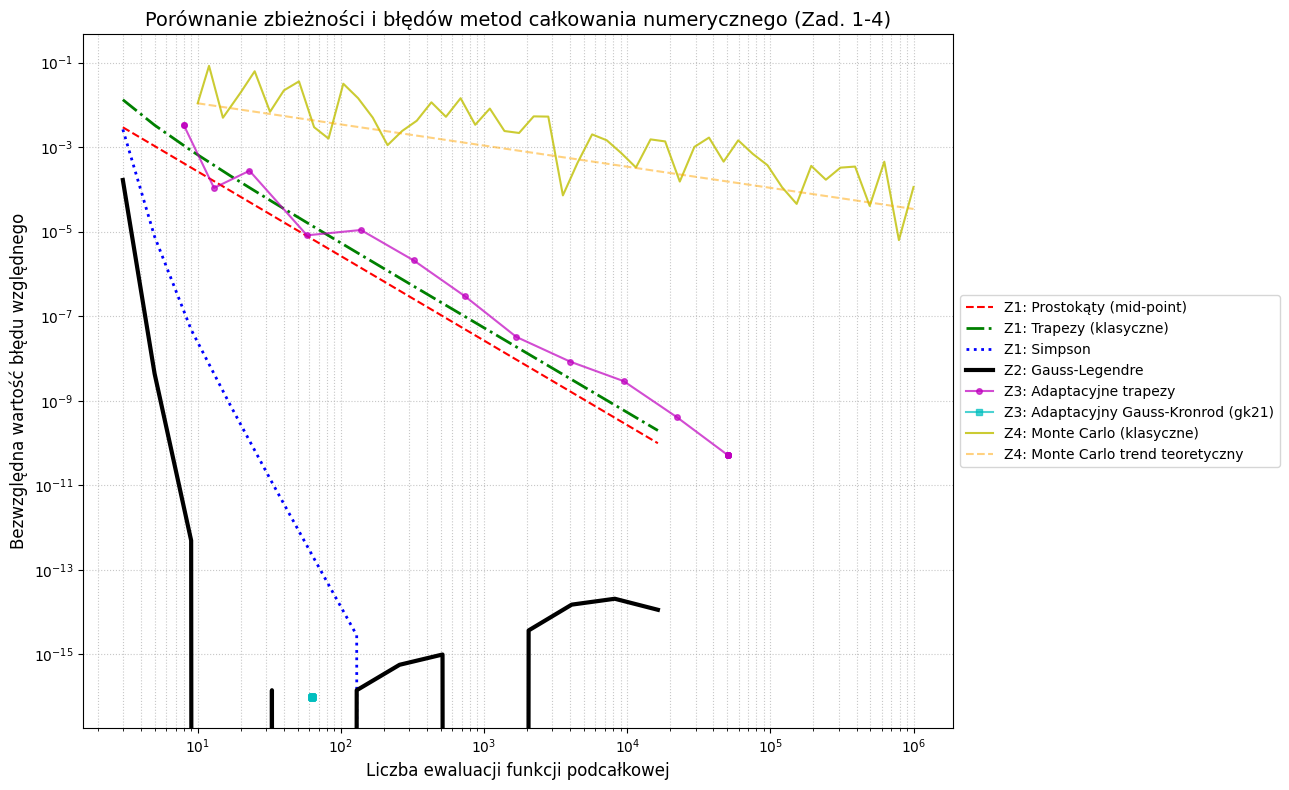

In [21]:
# chart
plt.figure(figsize=(13, 8))

# ex 1
plt.loglog(n_s, err_midpoint, 'r--', linewidth=1.5, label='Z1: Prostokąty (mid-point)')
plt.loglog(n_s, err_trapezoid, 'g-.', linewidth=2, label='Z1: Trapezy (klasyczne)')
plt.loglog(n_s, err_simpson, 'b:', linewidth=2, label='Z1: Simpson')

# ex 2
plt.loglog(n_s, err_legendre, 'k-', linewidth=3, label='Z2: Gauss-Legendre')

# ex 3
plt.loglog(evals_adapt_trapz, err_adapt_trapz, 'm-o', markersize=4, alpha=0.7, label='Z3: Adaptacyjne trapezy')
plt.loglog(evals_adapt_gk, err_adapt_gk, 'c-s', markersize=5, alpha=0.7, label='Z3: Adaptacyjny Gauss-Kronrod (gk21)')

# ex 4
plt.loglog(n_values_mc, err_mc, 'y-', linewidth=1.5, alpha=0.8, label='Z4: Monte Carlo (klasyczne)')

theoretical_rate = err_mc[0] * np.sqrt(n_values_mc[0]) / np.sqrt(n_values_mc)
plt.loglog(n_values_mc, theoretical_rate, color='orange', linestyle='--', alpha=0.5, label='Z4: Monte Carlo trend teoretyczny')

plt.title('Porównanie zbieżności i błędów metod całkowania numerycznego (Zad. 1-4)', fontsize=14)
plt.xlabel('Liczba ewaluacji funkcji podcałkowej', fontsize=12)
plt.ylabel('Bezwzględna wartość błędu względnego', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, which="both", linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()